<a href="https://colab.research.google.com/github/suai-mlb-2024/mlb-task1-trashez/blob/main/pandas_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы машинного обучения: лабораторная работа №1
## Задание 3. Знакомство с Pandas

В этом задании необходимо научиться базовым приемам работы с данными. Необходимо загрузить заданный по варианту датасет, провести разведочный анализ данных, сформулировать гипотезы о возможном значении всех полей в датасете, проверить эти гипотезы, и ответить на вопросы по данным. <!-- Если в конкретном задании не указано иное, проводить очистку данных (удаление пустых и невалидных значений) не нужно. -->

### Цель

Знакомство с разведочным анализом данных и применение Pandas для извлечения информации

### Оценивание и баллы

За это задание в общей сложности можно получить до 7 баллов. Задание частично проверяется автоматически, а частично будет оцениваться вручную. Чтобы получить максимальный балл,  необходимо успешно выполнить приведенные ниже задачи.

## Важные замечания

1. *Откройте этот файл в своем репозитории на GitHub и скопируйте адрес из адресной строки браузера. Перейдтие в [Google Colab](https://colab.research.google.com/), выберите `Файл -> Открыть ноутбук -> GitHub`, вставьте скопированный URL и нажмите кнопку поиска (кнопка с лупой справа от поля ввода строки для поиска). В Google Colab откроется копия этого ноутбука из персонального репозитория на GitHub.*
2. *Не удаляйте и не изменяйте имена переменных в ячейках с кодом ниже. Можно добавлять в каждую ячейку произвольное количество строк кода, главное - сохранить результат решения задачи в предопределенную (-ые) переменную (-ые) в соответствующей ячейке. Если этого не сделать, автоматические тесты не будут пройдены.*
3. *Чтобы сохранить работу, выбрите `Файл -> Сохранить копию на GitHub` и __вручную выберите правильный репозиторий из раскрывающегося списка__.*
4. *Если в процессе выполнения задания этот файл окажется испорчен, ознакомьтесь с инструкцией в ноутбуке [jupyter_assignment](jupyter_assignment.ipynb), раздел "Повторная сдача".*  


#### Задачи

#### 1. Определить номер варианта
Перейдите по ссылке из личного кабинета на Google Таблицу со списком студентов. Найдите свое ФИО в списке и запомните соответствующий порядковый номер (поле № п/п) в первом столбце. Заполните его в ячейке ниже и выполните ячейку. Если вы не можете найти себя в списке, обратитесь к своему преподавателю.

In [1]:
### BEGIN YOUR CODE

Student_ID = 13

### END YOUR CODE

Теперь выполните следующую ячейку. Она вычислит номер задания и выведет его.

In [2]:
datasets = [('Chipotle','https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'), ('US Air Carrier market in 2019','https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip'), ('Open Food Facts', 'https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/en.openfoodfacts.org.products.tsv.tar.bz2')]

dataset_id = None if Student_ID is None else Student_ID % 3
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Датасет '{datasets[dataset_id][0]}' доступен по следующей ссылке: {datasets[dataset_id][1]}")
    print(f"В заданиях ниже, где нужно выбрать вопрос, всегда выбирайте вопрос № {dataset_id+1}")

Датасет 'US Air Carrier market in 2019' доступен по следующей ссылке: https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip
В заданиях ниже, где нужно выбрать вопрос, всегда выбирайте вопрос № 2


Скачайте датасет с помощью команды `!wget <dataset_url>`, где `<dataset_url>` необходимо заменить на ссылку на датасет, появившуюся после выполнения предыдущей ячейки. При необходимости разархивируйте датасет, используя команды `!unzip`, `!tar` и др.

*Примечание: в Jupyter-ноутбуке можно использовать любые команды командного интерпретатора bash. Для этого необходимо поставить в ячейке с кодом восклицательный знак `!`, после которого записать команду bash со всеми необходимыми аргументами. Результат выполнения этой команды bash будет возвращен в Jupyter и его можно использовать в коде на Python.*

In [3]:
### BEGIN YOUR CODE

# Скачиваем файл
!wget https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip

# Распаковываем содержимое ZIP-архива
!unzip aircarrier_market_us_2019.zip
# !tar ...
# !gunzip ...

### END YOUR CODE

--2024-10-15 22:22:00--  https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10159563 (9.7M) [application/zip]
Saving to: ‘aircarrier_market_us_2019.zip.1’

aircarrier_market_u 100%[===================>]   9.69M  --.-KB/s    in 0.1s    

2024-10-15 22:22:01 (93.5 MB/s) - ‘aircarrier_market_us_2019.zip.1’ saved [10159563/10159563]

Archive:  aircarrier_market_us_2019.zip
replace aircarrier_market_us_2019.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

##### 2. Загрузите датасет в pandas.DataFrame, сохраните его в переменной `df`. Cконвертируйте названия столбцов в нижний регистр

In [4]:
import pandas as pd

# Загружаем CSV-файл в DataFrame
df = pd.read_csv('aircarrier_market_us_2019.csv')

# Приводим названия столбцов к нижнему регистру
df.columns = df.columns.str.lower()

# Выводим названия столбцов для проверки
print(df.columns)

Index(['passengers', 'freight', 'mail', 'distance', 'unique_carrier',
       'airline_id', 'unique_carrier_name', 'unique_carrier_entity', 'region',
       'carrier', 'carrier_name', 'carrier_group', 'carrier_group_new',
       'origin_airport_id', 'origin_airport_seq_id', 'origin_city_market_id',
       'origin', 'origin_city_name', 'origin_state_abr', 'origin_state_fips',
       'origin_state_nm', 'origin_country', 'origin_country_name',
       'origin_wac', 'dest_airport_id', 'dest_airport_seq_id',
       'dest_city_market_id', 'dest', 'dest_city_name', 'dest_state_abr',
       'dest_state_fips', 'dest_state_nm', 'dest_country', 'dest_country_name',
       'dest_wac', 'year', 'quarter', 'month', 'distance_group', 'class',
       'data_source'],
      dtype='object')


##### 3. Какие столбцы присутствуют в наборе данных? (0.25 балла)

In [5]:
# Получаем список столбцов
columns = df.columns.tolist()

# Выводим список столбцов
print(columns)

['passengers', 'freight', 'mail', 'distance', 'unique_carrier', 'airline_id', 'unique_carrier_name', 'unique_carrier_entity', 'region', 'carrier', 'carrier_name', 'carrier_group', 'carrier_group_new', 'origin_airport_id', 'origin_airport_seq_id', 'origin_city_market_id', 'origin', 'origin_city_name', 'origin_state_abr', 'origin_state_fips', 'origin_state_nm', 'origin_country', 'origin_country_name', 'origin_wac', 'dest_airport_id', 'dest_airport_seq_id', 'dest_city_market_id', 'dest', 'dest_city_name', 'dest_state_abr', 'dest_state_fips', 'dest_state_nm', 'dest_country', 'dest_country_name', 'dest_wac', 'year', 'quarter', 'month', 'distance_group', 'class', 'data_source']


##### 4. Ответьте на вопрос и сохраните ответ в переменной `answer1` (0.25 балла)

Вопросы:
1. Какое блюдо (`item_name`) заказывали чаще всего?
2. Сколько авиаперевозчиков (`carrier`) представлены в датасете?
3. По скольки продуктам в датасете имеется информация о содержании аллергенов (`allergens`)?

In [7]:
# Считаем количество уникальных значений в столбце 'carrier'
answer1 = df['carrier'].nunique()

# Выводим ответ, Количество авиаперевозчиков
print(answer1)

319


##### 5. Ответьте на вопрос и сохраните ответ в переменной `answer2` (0.5 балла)

Вопросы:
1. Сколько всего было заказов блюда, название которого сохранено в `answer1`?
2. Посчитайте общие суммарные количества перевезенных пассажиров (`passangers`), фунтов груза (`freight`) и почты (`mail`) на маршруте из Великобритании (UK) в США (US). В `answer2` запишите максимальное из трех получившихся чисел.
3. Сколько всего продуктов, относящихся к категории "молочные" (`Dairies,Milks`), с заполненным названием?

In [10]:
# Фильтруем данные для маршрутов из Великобритании (GB) в США (US)
uk_us_flights = df[(df['origin_country'] == 'GB') & (df['dest_country'] == 'US')]

# Суммируем пассажиров, груз и почту
total_passengers = uk_us_flights['passengers'].sum()
total_freight = uk_us_flights['freight'].sum()
total_mail = uk_us_flights['mail'].sum()

# Выбираем максимальное из трех значений
answer2 = max(total_passengers, total_freight, total_mail)

print(answer2)

903296879.0


##### 6. Ответьте на вопрос и сохраните ответ в переменной `answer3` (0.5 балла)

Вопросы:
1. Какой доход получила сеть Chipotle Mexican Grill на заказах, попавших в датасет?
2. Какой авиаперевозчик (`unique_carrier_name`) перевез больше всего груза (`mail` + `freight`)?
3. Как называется продукт категории `Fats` с максимальной жирностью, не превышающей 30 г на 100 г продукта?

In [11]:
# Создаем новый столбец с общим грузом (mail + freight)
df['total_cargo'] = df['mail'] + df['freight']

# Группируем данные по уникальному перевозчику и суммируем общий груз
cargo_per_carrier = df.groupby('unique_carrier_name')['total_cargo'].sum()

# Находим авиаперевозчика с максимальным значением груза
answer3 = cargo_per_carrier.idxmax()

print(answer3)

Federal Express Corporation


##### 7. Ответьте на вопрос и сохраните ответ в переменной `answer4` (0.5 балла)

Вопросы:
1. Каков средний доход с одного заказа?
2. Какое максимальное количество пассажиров одна авиакомпания смогла перевезти из США в другие страны за все время?
3. Какова энергетическая ценность в кДж продукта из России (`category_en`) имеющего максимальное содержание холистерина?

In [12]:
# Фильтруем данные для авиакомпаний, которые осуществляют рейсы из США
us_passengers = df[df['origin_country'] == 'US']

# Группируем данные по уникальному перевозчику и суммируем количество пассажиров
passengers_per_carrier = us_passengers.groupby('unique_carrier_name')['passengers'].sum()

# Находим максимальное количество пассажиров
answer4 = passengers_per_carrier.max()

print(answer4)

160592962.0


##### 8. Ответьте на вопрос и сохраните ответ в переменной `answer5` (1 балл)

Вопросы:
1. Сколько раз был заказан самый популярный напиток (Coke, Sprite, Mountain Dew и т.п.)?
2. Между какими двумя городами было перевезено наибольшее количество пассажиров? Учтите оба направления. Ответ запишите в виде списка из двух строк.
3. Привести названия всех аллергенов к нижнему регистру. Какой аллерген встречается в продуктах чаще всего?

In [13]:
# Группируем данные по парам городов (origin и destination) и суммируем количество пассажиров
passengers_between_cities = df.groupby(['origin', 'dest'])['passengers'].sum()

# Находим пару городов с максимальным количеством пассажиров
max_passengers = passengers_between_cities.idxmax()  # Пара городов
max_passengers_count = passengers_between_cities.max()  # Максимальное количество пассажиров

# Сохраняем ответ в виде списка
answer5 = [max_passengers[0], max_passengers[1]]

print(answer5)

['LAX', 'JFK']


##### 9. Ответьте на вопрос и сохраните ответ в переменной `answer6` (1 балл)

Вопросы:
1. Какой суммарный доход принесли напитки в заказах вегетарианцев?
2. Для пары городов из предыдущего вопроса найдите 3 авиакомпании, которые перевезли больше всего пассажиров. Посчитайте, какой процент от общего пассажиропотока между этими городами перевезла каждая из трех авиакомпаний. В `answer6` запишите найденные проценты в виде списка из трех чисел, округлив их до двух знаков после запятой.
3. Найти самый опасный продукт, содержащий наибольшее количество аллергенов.

In [14]:
# Фильтруем данные по городам LAX и JFK
filtered_data = df[(df['origin'].isin(['LAX', 'JFK'])) & (df['dest'].isin(['LAX', 'JFK']))]

# Группируем по авиакомпаниям и суммируем количество пассажиров
passengers_by_carrier = filtered_data.groupby('unique_carrier_name')['passengers'].sum()

# Находим общее количество пассажиров между этими городами
total_passengers = passengers_by_carrier.sum()

# Находим 3 авиакомпании с наибольшим количеством перевезенных пассажиров
top_carriers = passengers_by_carrier.nlargest(3)

# Вычисляем процент от общего пассажиропотока для каждой авиакомпании
percentage = (top_carriers / total_passengers) * 100

# Округляем до двух знаков после запятой
answer6 = percentage.round(2).tolist()

print(answer6)

[35.49, 29.99, 19.98]


##### 10. Ответьте на вопрос и сохраните ответ в переменной `answer7` (1 балл)

Вопросы:
1. Сколько было сделано вегетарианских заказов? Заказ не считается вегетарианским, если в нем были не вегетарианские блюда.
2. Для каждой страны найдите процент международного пассажиропотока (относительно США), используя общее количество пассажиров на рейсах класса F. В `answer7` запишите название страны с третьим по величине пассажиропотоком в/из США.
3. Переведите названия групп продуктов (`pnns_groups_1`, `pnns_groups_2`) в нижний регистр. В переменную `answer7` запишите список, содержащий три элемента: название группы продуктов 1, название группы продуктов 2 и среднее количество пищевых волокон (`fiber`) для седьмой по насыщенности пищевыми волокнами группы продуктов.

In [15]:
# Фильтруем данные по классу F
class_f_data = df[df['class'] == 'F']

# Группируем данные по стране назначения и суммируем количество пассажиров
passengers_by_country = class_f_data.groupby('dest_country_name')['passengers'].sum()

# Находим общий пассажиропоток из США
total_passengers_us = class_f_data['passengers'].sum()

# Вычисляем процент международного пассажиропотока для каждой страны
percentage_by_country = (passengers_by_country / total_passengers_us) * 100

# Находим страну с третьим по величине пассажиропотоком
answer7 = percentage_by_country.nlargest(3).index[2]  # Индекс 2 соответствует третьему по величине

print(answer7)

Mexico


##### 11. Ответьте на вопрос и сохраните ответ в переменной `answer8` (1 балл)

Вопросы:
1. Какой соус или дополнительный ингредиент по выбору (`choice_description`) чаще всего берут вместе с бурито с курицей (Chicken Burrito)?
2. В каком месяце пассажиропоток между городами, записанными в переменную `answer5`, был максимальным?
3. Какое название у группы продуктов `pnns_groups_2`, явояющейся наиболее сбалансированной с точки зрения среднего содержания калорий, жиров и углеводов? Под "сбалансированной" понимать близость БЖУ к пропорции 1:1:4.

In [16]:
# Фильтруем данные по городам из answer5
filtered_data = df[(df['origin'].isin(answer5)) & (df['dest'].isin(answer5))]

# Группируем данные по месяцу и суммируем количество пассажиров
monthly_passengers = filtered_data.groupby('month')['passengers'].sum()

# Находим месяц с максимальным пассажиропотоком
answer8 = monthly_passengers.idxmax()  # Возвращает месяц с максимальным пассажиропотоком

print(answer8)

5


##### 12. Визуализируйте данные в соответствии с заданием (1 балл)

1. Построить гистограмму распределения общей стоимости заказов. Найти и отметить на графике средний чек и медианную стоимость заказа.
2. Постройте стековую столбчатую гистограмму пассажиропотока с разбивкой по городам (отдельные столбцы) и авиакомпаниям (разбивка внутри столбца).
3. Построить столбчатую гистограмму усредненной по группам продуктов энергетической ценности, с группировкой по `pnns_groups_1`.


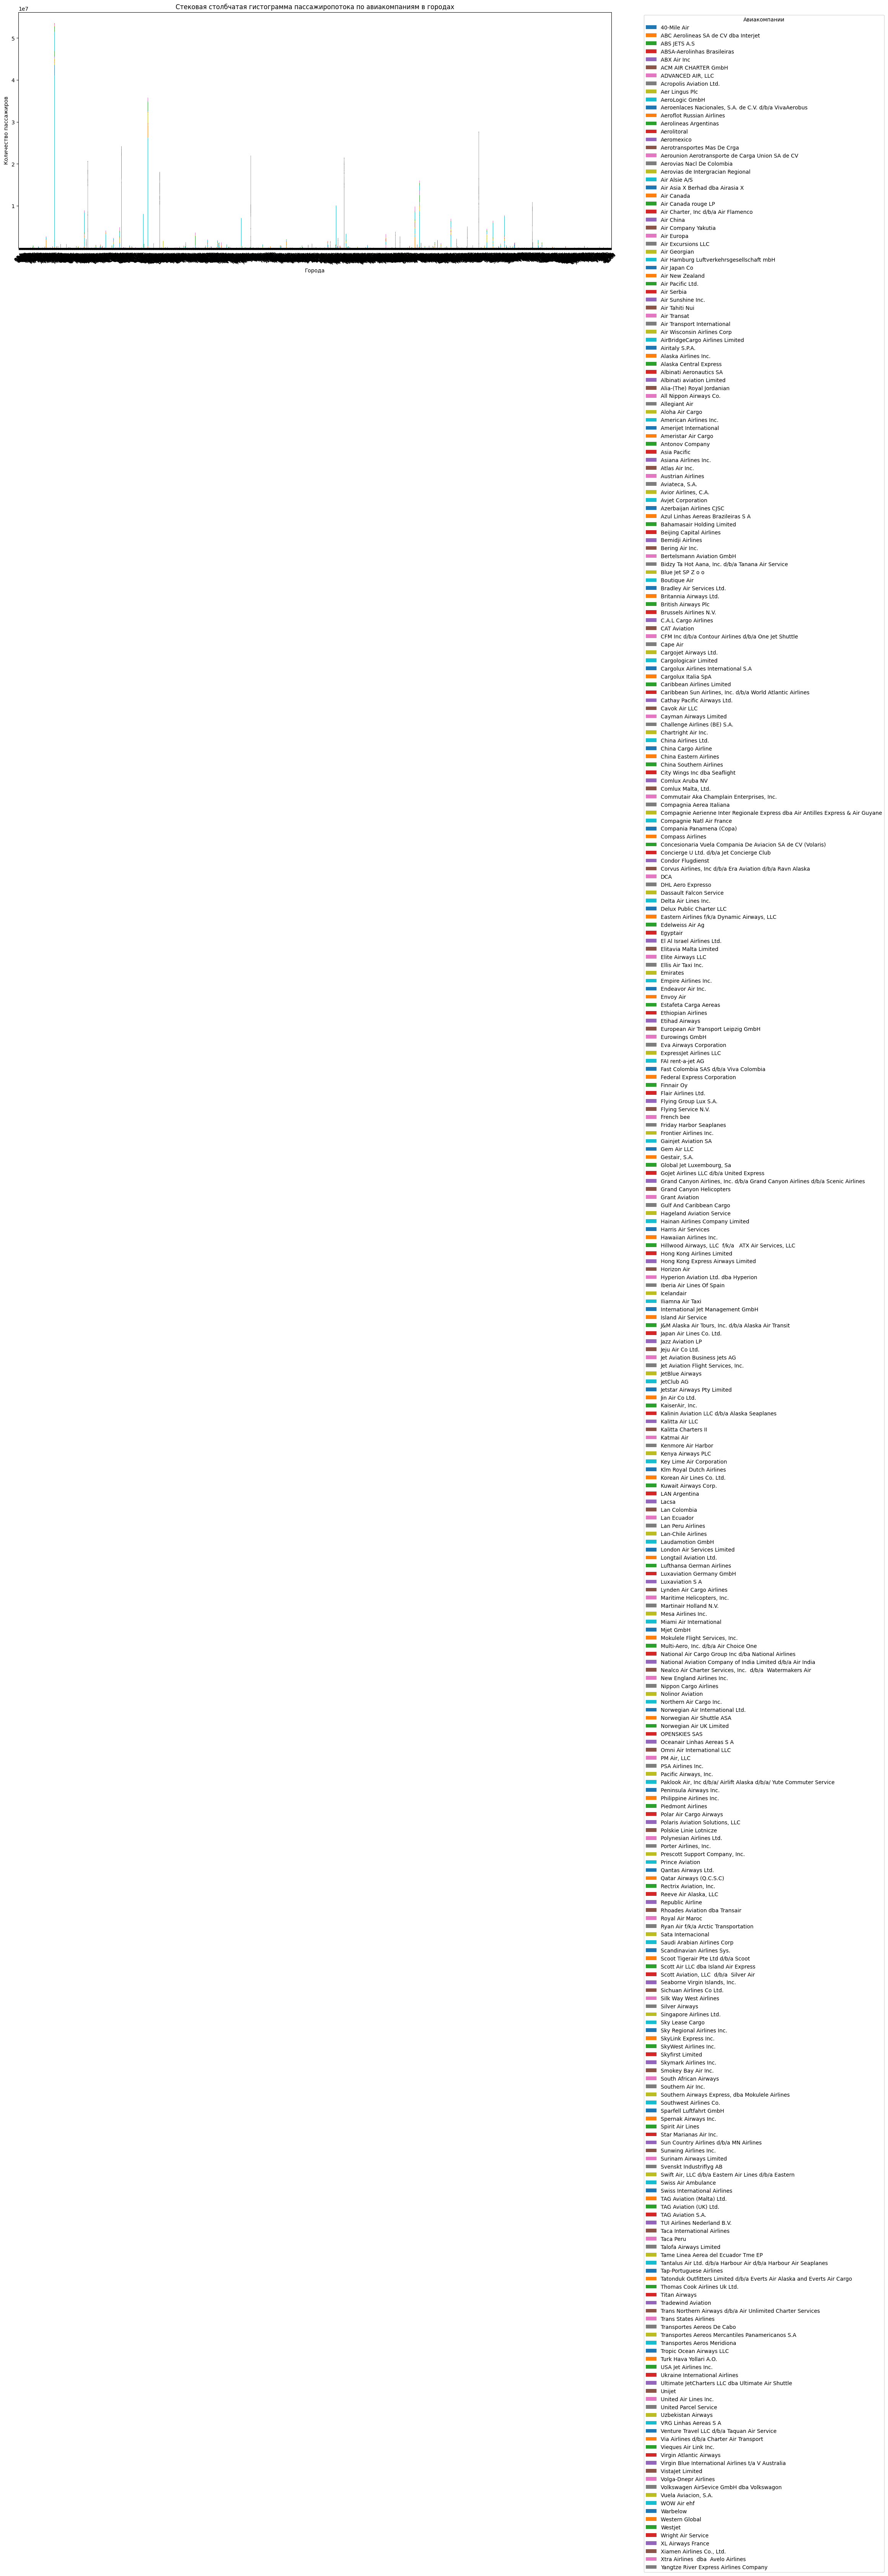

In [6]:
import matplotlib.pyplot as plt

# Группируем данные по городам и авиакомпаниям, суммируя количество пассажиров
passenger_flow = df.groupby(['origin', 'unique_carrier_name'])['passengers'].sum().unstack()

# Построение стековой столбчатой гистограммы
passenger_flow.plot(kind='bar', stacked=True, figsize=(20, 8))  # Увеличиваем размер графика

# Настройка графика
plt.title('Стековая столбчатая гистограмма пассажиропотока по авиакомпаниям в городах')
plt.xlabel('Города')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=45)
plt.legend(title='Авиакомпании', bbox_to_anchor=(1.05, 1), loc='upper left')

# Показать график
plt.show()